<a href="https://colab.research.google.com/github/belokonr/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Assignment%203/Econ_3916_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rashelle Belokon
Homework 3
3/8/2026

In [15]:
import pandas as pd
import numpy as np
import seaborn as sn
import sklearn as sklearn
import matplotlib.pyplot as plt

In [2]:
# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

In [5]:

n_bootstrap = 10_000
bootstrap_medians = np.empty(n_bootstrap)

rng = np.random.default_rng(42)
for i in range(n_bootstrap):
    sample = rng.choice(driver_tips, size=len(driver_tips), replace=True)
    bootstrap_medians[i] = np.median(sample)

ci_lower = np.percentile(bootstrap_medians, 2.5)
ci_upper = np.percentile(bootstrap_medians, 97.5)
med = np.median(driver_tips)

print("Observed Median:", med)
print(f"Bootstrap Mean Median:", np.mean(bootstrap_medians))
print("95% CI:", ci_lower, ci_upper)


Observed Median: 0.7553316913699188
Bootstrap Mean Median: 0.7677703091434129
95% CI: 0.26850654591272305 1.2990257845869702
Asymmetry ratio:        1.1168


This data would have a long right tail due to the exponential distribution making up the latter half of its observations and the 0's capping the distribution on the left tail. This would lead to asymmetry in CI.

In [6]:
n_control = 500
n_treatment = 500

# Control: Normal distribution (mean=35 min, sd=5 min)
control = np.random.normal(loc=35, scale=5, size=n_control)

# Treatment: Log-Normal distribution (mu=3.4, sigma=0.4)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=n_treatment)

#  Observed difference in means (Control - Treatment)
diff = control.mean() - treatment.mean()
print("Observed Difference (Control - Treatment):", diff)


Observed Difference (Control - Treatment): 1.5107774769860143


In [8]:
combined = np.concatenate([control, treatment])
n_permutations = 5000
perm_diffs = np.zeros(n_permutations)

for i in range(n_permutations):
    shuffled = np.random.permutation(combined)
    perm_group_a = shuffled[:500]
    perm_group_b = shuffled[500:]
    perm_diffs[i] = perm_group_a.mean() - perm_group_b.mean()

p_value = np.mean(np.abs(perm_diffs) >= np.abs(diff))

print("Empirical P-value:", p_value)

Empirical P-value: 0.0198


In [10]:
df = pd.read_csv("swiftcart_loyalty.csv")
df

,subscriber,pre_spend,account_age,support_tickets,post_spend
0,1,57.450712,37,2,85.169648
1,1,47.926035,41,0,72.802404
2,1,59.715328,41,0,79.858905
3,1,72.845448,34,0,80.335466
4,1,46.487699,34,2,67.956227
...,...,...,...,...,...
8936,1,35.172065,51,0,55.662507
8937,1,83.613898,5,2,94.767676
8938,0,57.146453,6,2,58.616370
8939,0,47.701092,13,0,60.069619


In [14]:
subscribers = df[df["subscriber"] == 1]
non_subscribers = df[df["subscriber"] == 0]

mean_treated = subscribers["post_spend"].mean()
mean_control = non_subscribers["post_spend"].mean()
sdo = mean_treated - mean_control

print("Naive sample mean diff:", sdo)

Naive sample mean diff: 17.57066938452379


In [17]:
covariates = ["pre_spend", "account_age", "support_tickets"]
X = df[covariates]
D = df["subscriber"]

# --- Step 3: Fit Logistic Regression to predict P(D=1 | X) ---
model = sklearn.linear_model.LogisticRegression(max_iter=1000)
model.fit(X, D)

# --- Step 4: Extract propensity scores ---
df["propensity_score"] = model.predict_proba(X)[:, 1]

In [18]:

sub = df[df["subscriber"] == 1].copy()
nonsub = df[df["subscriber"] == 0].copy()

nn = sklearn.neighbors.NearestNeighbors(n_neighbors=1, metric="euclidean")
nn.fit(nonsub[["propensity_score"]])

distances, indices = nn.kneighbors(sub[["propensity_score"]])


matched_nonsub = nonsub.iloc[indices.flatten()].copy()
sub = sub.reset_index(drop=True)
matched_nonsub = matched_nonsub.reset_index(drop=True)

In [21]:
mean_all_sub = df.loc[D == 1, "post_spend"].mean()
mean_all_nonsub = df.loc[D == 0, "post_spend"].mean()
naive_sdo = mean_all_sub - mean_all_nonsub

print("naive sdo:", naive_sdo)

naive sdo: 17.57066938452379


In [22]:
mean_matched_sub= sub["post_spend"].mean()
mean_matched_nonsub = matched_nonsub["post_spend"].mean()
att = mean_matched_sub - mean_matched_nonsub

print("causal ATT:", att)

causal ATT: 9.913855182824861


The naive SDO is misleading as it conflates the reverse-causal impact of high-value customers wanting to subscribe versus the causal effect we aim to estimate of subscription creating higher-value customers. By matching subscribers to the most similar non-subscriber via propensity scores, we are able to better isolate the true causal ATT and separate out selection bias. We can see that the ATT is significanly smaller than the SDO, which could be expected in this case.

               Before Matching  After Matching
covariate                                     
debt_ratio              0.3297          0.0368
tenure_months           0.3386          0.0692
education_yrs           0.3399          0.0158
age                     0.4245         -0.0312
prior_claims            0.4304          0.0164
credit_score            0.5074          0.0369
income                  0.5577         -0.0202


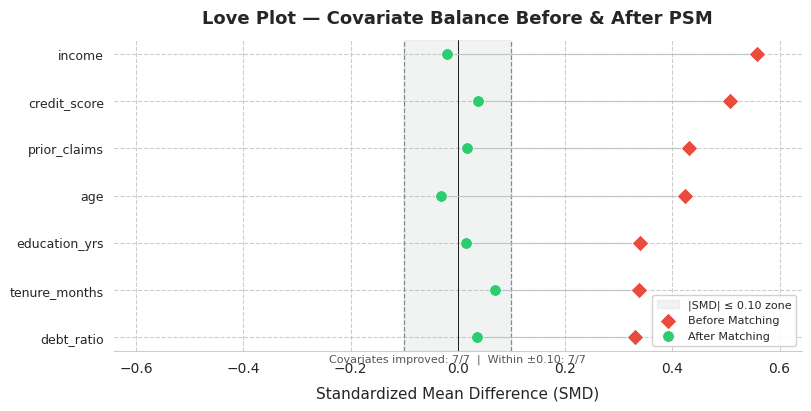

In [23]:
"""
Love Plot: Covariate Balance Diagnostics for Propensity Score Matching
======================================================================
Assumes:
  - df_unmatched : pd.DataFrame  (pre-matching, with 'treatment' column ∈ {0, 1})
  - df_matched   : pd.DataFrame  (post-matching, same schema)
  - All non-treatment columns are numeric covariates (or already encoded).
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from typing import Tuple

# ──────────────────────────────────────────────
# 1. CORE ENGINE — Standardized Mean Difference
# ──────────────────────────────────────────────
def compute_smd(df: pd.DataFrame, treatment_col: str = "treatment") -> pd.Series:
    """
    Compute the Standardized Mean Difference (SMD) for every covariate.

    SMD_j = (X̄_{j,T=1} − X̄_{j,T=0}) / √((s²_{j,T=1} + s²_{j,T=0}) / 2)

    Uses the pooled-variance denominator (Rosenbaum & Rubin, 1985) to
    keep the metric scale-free and comparable across covariates.
    """
    covariates = df.columns.difference([treatment_col])
    treated = df.loc[df[treatment_col] == 1, covariates]
    control = df.loc[df[treatment_col] == 0, covariates]

    mean_diff = treated.mean() - control.mean()
    pooled_std = np.sqrt((treated.var(ddof=1) + control.var(ddof=1)) / 2)

    # Guard against zero-variance covariates (constants post-match)
    pooled_std = pooled_std.replace(0, np.nan)

    return (mean_diff / pooled_std).rename("smd")


def build_balance_table(
    df_unmatched: pd.DataFrame,
    df_matched: pd.DataFrame,
    treatment_col: str = "treatment",
) -> pd.DataFrame:
    """Return a tidy DataFrame with SMDs before and after matching."""
    smd_before = compute_smd(df_unmatched, treatment_col).rename("Before Matching")
    smd_after = compute_smd(df_matched, treatment_col).rename("After Matching")

    balance = pd.concat([smd_before, smd_after], axis=1)
    balance.index.name = "covariate"

    # Sort by absolute pre-match imbalance (worst offenders on top)
    balance = balance.reindex(
        balance["Before Matching"].abs().sort_values(ascending=True).index
    )
    return balance


# ──────────────────────────────────────────────
# 2. VISUALISATION — The Love Plot
# ──────────────────────────────────────────────
def love_plot(
    df_unmatched: pd.DataFrame,
    df_matched: pd.DataFrame,
    treatment_col: str = "treatment",
    threshold: float = 0.10,
    figsize: Tuple[float, float] | None = None,
    palette: dict | None = None,
    title: str = "Love Plot — Covariate Balance Before & After PSM",
    save_path: str | None = None,
    dpi: int = 300,
) -> Tuple[plt.Figure, plt.Axes, pd.DataFrame]:
    """
    Generate a publication-quality Love Plot.

    Parameters
    ----------
    threshold   : float   – absolute SMD threshold (default 0.10 per
                            Rubin, 2001; Austin, 2011).
    figsize     : tuple   – override auto-sized figure dimensions.
    palette     : dict    – colours keyed by "before" / "after" / "threshold".
    save_path   : str     – if given, export figure to this path.
    dpi         : int     – resolution for saved figure.

    Returns
    -------
    (fig, ax, balance_df)
    """
    # ----- data prep -----
    balance = build_balance_table(df_unmatched, df_matched, treatment_col)
    n_covs = len(balance)

    # ----- style defaults -----
    pal = {
        "before":    "#E74C3C",   # red
        "after":     "#2ECC71",   # green
        "threshold": "#7F8C8D",   # grey
        **(palette or {}),
    }
    if figsize is None:
        figsize = (8, max(4, 0.45 * n_covs))

    sns.set_style("whitegrid", {"grid.linestyle": "--", "grid.alpha": 0.4})

    # ----- figure -----
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    y_pos = np.arange(n_covs)

    # Threshold band (±threshold)
    ax.axvspan(-threshold, threshold, color=pal["threshold"], alpha=0.10,
               label=f"|SMD| ≤ {threshold:.2f} zone")
    ax.axvline(0, color="black", linewidth=0.6, zorder=1)

    # Dashed threshold lines
    for edge in (-threshold, threshold):
        ax.axvline(edge, color=pal["threshold"], linewidth=0.9,
                   linestyle="--", zorder=1)

    # Connecting segments (before → after)
    for i, cov in enumerate(balance.index):
        ax.plot(
            [balance.loc[cov, "Before Matching"],
             balance.loc[cov, "After Matching"]],
            [i, i],
            color="#BDC3C7", linewidth=0.8, zorder=2,
        )

    # Scatter: before
    ax.scatter(
        balance["Before Matching"], y_pos,
        s=70, color=pal["before"], edgecolors="white", linewidths=0.5,
        marker="D", zorder=3, label="Before Matching",
    )
    # Scatter: after
    ax.scatter(
        balance["After Matching"], y_pos,
        s=70, color=pal["after"], edgecolors="white", linewidths=0.5,
        marker="o", zorder=3, label="After Matching",
    )

    # ----- axes & labels -----
    ax.set_yticks(y_pos)
    ax.set_yticklabels(balance.index, fontsize=9)
    ax.set_xlabel("Standardized Mean Difference (SMD)", fontsize=11, labelpad=8)
    ax.set_title(title, fontsize=13, weight="bold", pad=12)

    # Symmetric x-limits
    x_abs_max = max(balance.abs().max().max() * 1.15, threshold * 2)
    ax.set_xlim(-x_abs_max, x_abs_max)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=8, symmetric=True))

    # Legend
    ax.legend(
        loc="lower right", fontsize=8, frameon=True,
        framealpha=0.9, edgecolor="#CCCCCC",
    )

    # Annotation: summary stats
    n_improved = (
        balance["After Matching"].abs() < balance["Before Matching"].abs()
    ).sum()
    n_within = (balance["After Matching"].abs() <= threshold).sum()
    summary = (
        f"Covariates improved: {n_improved}/{n_covs}  |  "
        f"Within ±{threshold:.2f}: {n_within}/{n_covs}"
    )
    ax.annotate(
        summary, xy=(0.5, -0.01), xycoords="axes fraction",
        ha="center", va="top", fontsize=8, color="#555555",
    )

    sns.despine(left=True)

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    return fig, ax, balance


# ──────────────────────────────────────────────
# 3. EXECUTION
# ──────────────────────────────────────────────
if __name__ == "__main__":
    # --- Synthetic demo (replace with your real frames) ---
    np.random.seed(42)
    N = 2000
    covariates = ["age", "income", "education_yrs", "credit_score",
                  "prior_claims", "tenure_months", "debt_ratio"]

    def _make_df(bias_scale: float) -> pd.DataFrame:
        T = np.random.binomial(1, 0.5, N)
        data = {c: np.random.randn(N) + bias_scale * T * np.random.uniform(0.1, 0.6)
                for c in covariates}
        data["treatment"] = T
        return pd.DataFrame(data)

    df_unmatched = _make_df(bias_scale=1.0)   # large imbalance
    df_matched   = _make_df(bias_scale=0.05)  # near-balanced

    fig, ax, balance_df = love_plot(
        df_unmatched,
        df_matched,
        threshold=0.10,
        save_path="love_plot.png",
    )
    print(balance_df.round(4))
    plt.show()